In [2]:
import pandas as pd
import numpy as np
import datetime as dt

In [3]:
clicks = pd.read_csv('../data/raw/JD_click_data.csv')
orders = pd.read_csv('../data/raw/JD_order_data.csv')
display(clicks.head(5))
display(orders.head(5))

,sku_ID,user_ID,request_time,channel
0,a234e08c57,4c3d6d10c2,2018-03-01 23:57:53,wechat
1,6449e1fd87,-,2018-03-01 16:13:48,wechat
2,09b70fcd83,2791ec4485,2018-03-01 22:10:51,wechat
3,09b70fcd83,eb0718c1c9,2018-03-01 16:34:08,wechat
4,09b70fcd83,59f84cf342,2018-03-01 22:20:35,wechat


,order_ID,user_ID,sku_ID,order_date,order_time,quantity,type,promise,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,gift_item,dc_ori,dc_des
0,d0cf5cc6db,0abe9ef2ce,581d5b54c1,2018-03-01,2018-03-01 17:14:25.0,1,2,-,89.0,79.0,0.0,10.0,0.0,0.0,0,4,28
1,7444318d01,33a9e56257,067b673f2b,2018-03-01,2018-03-01 11:10:40.0,1,1,2,99.9,53.9,5.0,41.0,0.0,0.0,0,28,28
2,f973b01694,4ea3cf408f,623d0a582a,2018-03-01,2018-03-01 09:13:26.0,1,1,2,78.0,58.5,19.5,0.0,0.0,0.0,0,28,28
3,8c1cec8d4b,b87cb736cb,fc5289b139,2018-03-01,2018-03-01 21:29:50.0,1,1,2,61.0,35.0,0.0,26.0,0.0,0.0,0,4,28
4,d43a33c38a,4829223b6f,623d0a582a,2018-03-01,2018-03-01 19:13:37.0,1,1,1,78.0,53.0,19.0,0.0,0.0,6.0,0,3,16


In [6]:
display(clicks[(clicks['user_ID'] == '0abe9ef2ce') & (clicks['sku_ID'] == '581d5b54c1')])

,sku_ID,user_ID,request_time,channel
75660,581d5b54c1,0abe9ef2ce,2018-03-01 17:09:41,mobile
75703,581d5b54c1,0abe9ef2ce,2018-03-01 17:07:02,mobile


In [4]:
print(clicks.shape)
print(orders.shape)

(20214515, 4)
(549989, 17)


In [5]:
print(len(clicks['sku_ID'].unique()))
print(len(clicks['user_ID'].unique()))
print(len(orders['sku_ID'].unique()))
print(len(orders['user_ID'].unique()))

31867
2557837
9159
454897


In [4]:
clicks['request_time'] = pd.to_datetime(clicks['request_time'])

clicks['date'] = clicks['request_time'].dt.date
clicks['hour'] = clicks['request_time'].dt.hour
clicks['dayofweek'] = clicks['request_time'].dt.dayofweek  
# 0=Mon

display(clicks.head(5))

,sku_ID,user_ID,request_time,channel,date,hour,dayofweek
0,a234e08c57,4c3d6d10c2,2018-03-01 23:57:53,wechat,2018-03-01,23,3
1,6449e1fd87,-,2018-03-01 16:13:48,wechat,2018-03-01,16,3
2,09b70fcd83,2791ec4485,2018-03-01 22:10:51,wechat,2018-03-01,22,3
3,09b70fcd83,eb0718c1c9,2018-03-01 16:34:08,wechat,2018-03-01,16,3
4,09b70fcd83,59f84cf342,2018-03-01 22:20:35,wechat,2018-03-01,22,3


In [6]:
clicks['user_ID'] = clicks['user_ID'].replace('-', pd.NA)
clicks.info()
clicks.isna().mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20214515 entries, 0 to 20214514
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   sku_ID        object        
 1   user_ID       object        
 2   request_time  datetime64[ns]
 3   channel       object        
 4   date          object        
 5   hour          int32         
 6   dayofweek     int32         
dtypes: datetime64[ns](1), int32(2), object(4)
memory usage: 925.3+ MB


sku_ID          0.000000
user_ID         0.114196
request_time    0.000000
channel         0.000000
date            0.000000
hour            0.000000
dayofweek       0.000000
dtype: float64

Time Patterns

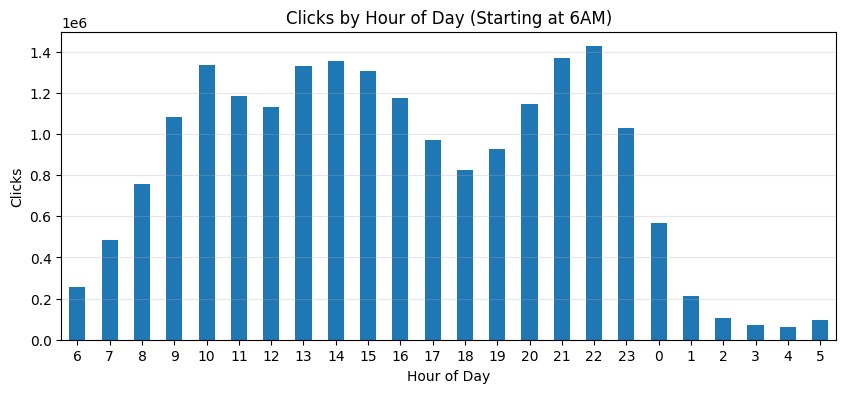

In [16]:
import matplotlib.pyplot as plt
hourly_clicks = clicks.groupby('hour').size()

hour_order = list(range(6, 24)) + list(range(0, 6))

# Reindex to enforce order (fill missing hours with 0 if needed)
hourly_clicks = hourly_clicks.reindex(hour_order, fill_value=0)

plt.figure(figsize=(10, 4))
hourly_clicks.plot(kind='bar')
plt.title('Clicks by Hour of Day (Starting at 6AM)')
plt.xlabel('Hour of Day')
plt.ylabel('Clicks')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

<AxesSubplot: title={'center': 'Clicks by Day of Week'}, xlabel='dayofweek'>

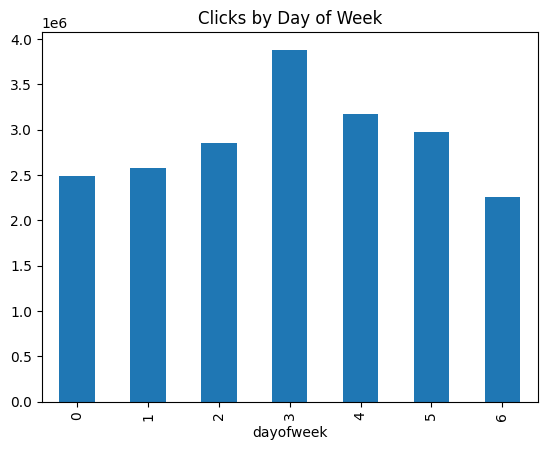

In [10]:
dow_clicks = clicks.groupby('dayofweek').size()

dow_clicks.plot(kind='bar', title='Clicks by Day of Week')

User-level

In [7]:
clicks['channel'].value_counts(normalize=True)

channel
app       0.747355
wechat    0.130239
pc        0.050654
mobile    0.048224
others    0.023527
Name: proportion, dtype: float64

In [13]:
user_clicks = clicks.groupby(['user_ID','date']).size()

user_clicks.describe()

count    4.100697e+06
mean     4.366598e+00
std      7.144638e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      7.060000e+02
dtype: float64

<AxesSubplot: >

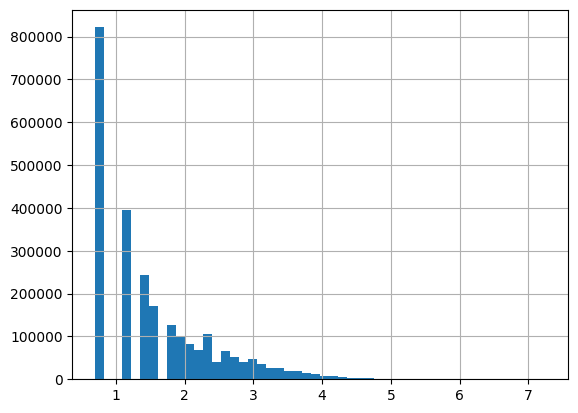

In [12]:
np.log1p(user_clicks).hist(bins=50)

/tmp/ipykernel_242400/3020330254.py:14: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(fn, parse_dates=['first_click_time','first_order_time'], infer_datetime_format=True)


Rows in result: 415311
Unique users: 373835
Unique skus: 8390


,clicks_before_order,days_between
count,415311.000000,415311.000000
mean,8.371485,0.809145
std,9.476287,3.163539
min,0.000000,-30.154340
25%,2.000000,0.002245
50%,6.000000,0.009792
75%,10.000000,0.182436
max,280.000000,30.938391


Fraction with days_between <= 0: 5.859%
Fraction with zero clicks before order: 5.854%

Top 15 SKUs by matched user-sku pairs:


sku
068f4481b3    22305
3c79df1d80    13718
8dc4a01dec     9008
fbce41fd82     7724
904fbf8b97     7275
ca7647a231     6175
38d636d2a6     5964
adfedb6893     5198
7e4cb4952a     5125
d47c6ca631     4917
589c2b865b     4846
5f58bfd286     3673
c4ea4afceb     3642
9e452b5aee     3636
4b65db43ac     3397
Name: count, dtype: int64


Top 15 users by ordered SKUs in this dataset:


user_id
ba740db18f    16
2dacf67f01    12
ccdf9b48fc    10
2bfc7491c8    10
b90ce0dbdc    10
9766a74a13    10
8ea5858820    10
5c209f9405    10
707dad64f8     9
e282168f52     8
ed33ff8f8b     8
0199a3a375     8
61aab8e7fa     8
98c3dc50aa     8
e207260ff7     8
Name: count, dtype: int64

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


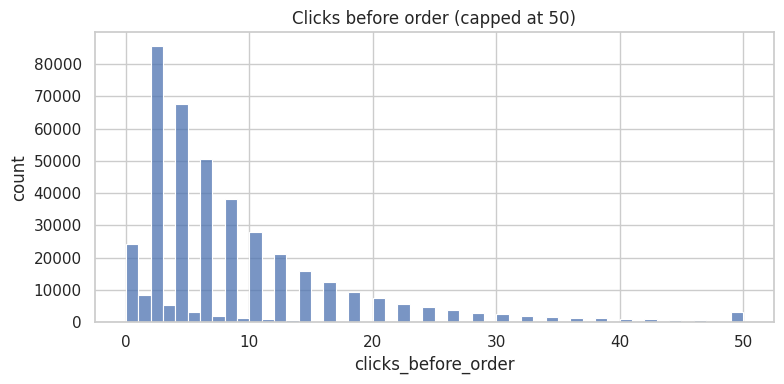

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


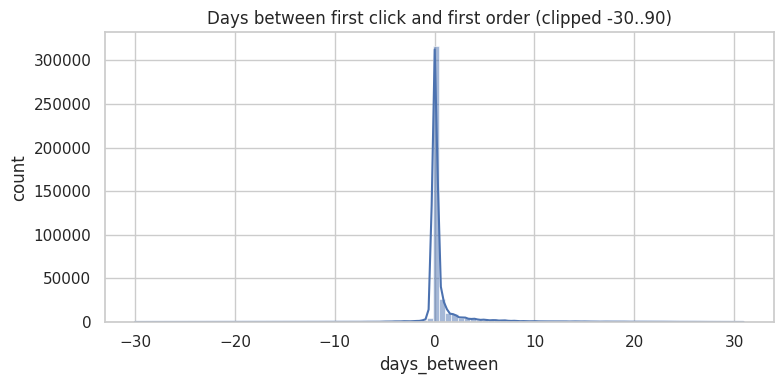

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


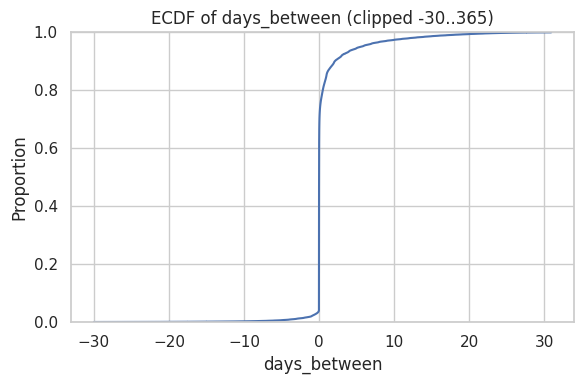

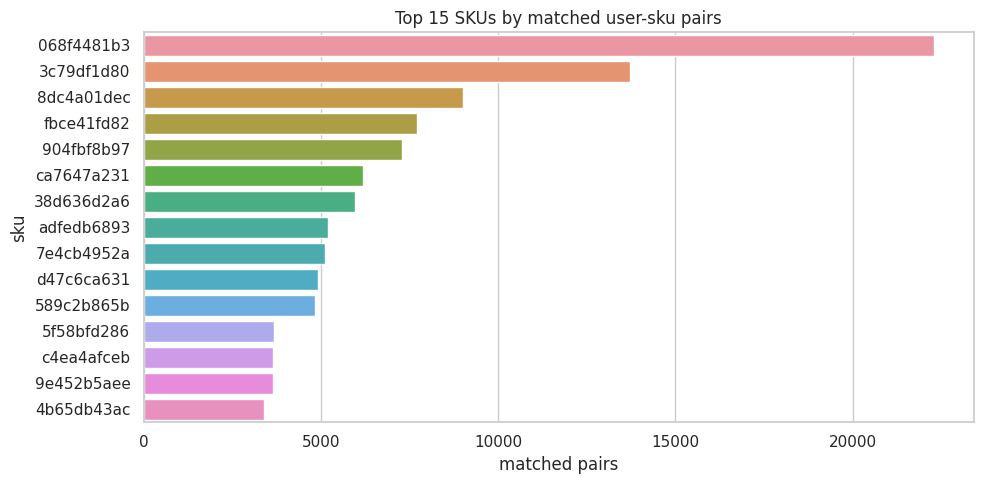

Saved plots and a filtered CSV to exploration_outputs


In [1]:
# Data exploration for click_to_order_metrics_sqlite_fixed.csv
# Loads the metrics CSV, prints summary statistics, and plots distributions.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style='whitegrid')

fn = Path('click_to_order_metrics_sqlite_fixed.csv')
if not fn.exists():
    print(f"File not found: {fn}. Please run compute_click_order_metrics.py with --use_sqlite first.")
else:
    df = pd.read_csv(fn, parse_dates=['first_click_time','first_order_time'], infer_datetime_format=True)
    print('Rows in result:', len(df))
    print('Unique users:', df['user_id'].nunique())
    print('Unique skus:', df['sku'].nunique())

    # Basic distributions
    display(df[['clicks_before_order','days_between']].describe())

    # Fraction where days_between <= 0
    frac_nonpositive = (df['days_between'] <= 0).mean()
    print(f'Fraction with days_between <= 0: {frac_nonpositive:.3%}')

    # Fraction with zero clicks before order
    frac_zero_clicks = (df['clicks_before_order'] == 0).mean()
    print(f'Fraction with zero clicks before order: {frac_zero_clicks:.3%}')

    # Top SKUs by number of (user,sku) pairs
    top_skus = df['sku'].value_counts().head(15)
    print('\nTop 15 SKUs by matched user-sku pairs:')
    display(top_skus)

    # Top users by number of ordered SKUs
    top_users = df['user_id'].value_counts().head(15)
    print('\nTop 15 users by ordered SKUs in this dataset:')
    display(top_users)

    # Plots directory
    outdir = Path('../outputs/exploration')
    outdir.mkdir(exist_ok=True)

    # Histogram of clicks_before_order (log-scale for counts)
    plt.figure(figsize=(8,4))
    sns.histplot(df['clicks_before_order'].clip(upper=50), bins=50, kde=False)
    plt.title('Clicks before order (capped at 50)')
    plt.xlabel('clicks_before_order')
    plt.ylabel('count')
    plt.tight_layout()
    p1 = outdir / 'hist_clicks_before_order.png'
    plt.savefig(p1)
    display(plt.gcf())
    plt.close()

    # KDE / histogram of days_between (capped)
    plt.figure(figsize=(8,4))
    sns.histplot(df['days_between'].dropna().clip(-30,90), bins=100, kde=True)
    plt.title('Days between first click and first order (clipped -30..90)')
    plt.xlabel('days_between')
    plt.ylabel('count')
    plt.tight_layout()
    p2 = outdir / 'hist_days_between.png'
    plt.savefig(p2)
    display(plt.gcf())
    plt.close()

    # CDF of days between
    plt.figure(figsize=(6,4))
    data = df['days_between'].dropna()
    sns.ecdfplot(data.clip(-30,365))
    plt.title('ECDF of days_between (clipped -30..365)')
    plt.xlabel('days_between')
    plt.tight_layout()
    p3 = outdir / 'ecdf_days_between.png'
    plt.savefig(p3)
    display(plt.gcf())
    plt.close()

    # Bar chart of top 15 SKUs
    plt.figure(figsize=(10,5))
    sns.barplot(x=top_skus.values, y=top_skus.index)
    plt.title('Top 15 SKUs by matched user-sku pairs')
    plt.xlabel('matched pairs')
    plt.tight_layout()
    p4 = outdir / 'top15_skus.png'
    plt.savefig(p4)
    display(plt.gcf())
    plt.close()

    # Save summary CSVs
    df[['user_id','sku','first_click_time','first_order_time','clicks_before_order','days_between']].to_csv(outdir / 'filtered_results_sample.csv', index=False)
    print('Saved plots and a filtered CSV to', outdir)


# User Click Behavior (Aggregated)

This section analyzes **user-level aggregated click behavior** from `../data/processed/user_click_behavior.csv`.
Each row represents one user and summarizes their activity across the full click log.

**Why this matters:** It lets us understand *how users behave* (engagement, timing, channel usage) and *which SKUs dominate user attention*, without loading the full clickstream.

**Important limitation:** Because this file is already aggregated per user, we can only compute SKU and time patterns **at the user level** (e.g., a user's most-clicked SKU). We cannot see every single click event here.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load user-level aggregated click behavior 
beh = pd.read_csv('../data/processed/user_click_behavior.csv')

# Quick look at columns and row count
print('rows:', len(beh), 'cols:', len(beh.columns))
display(beh.head())

rows: 2557836 cols: 21


,user_id,total_clicks,active_days,avg_clicks_per_day,first_click_time,last_click_time,active_span_days,unique_skus,top_sku,top_sku_clicks,...,unique_channels,top_channel,top_channel_clicks,top_channel_share,peak_hour,peak_hour_clicks,peak_hour_share,peak_dow,peak_dow_clicks,peak_dow_share
0,00000e0594,3,1,3.0,2018-03-30 11:00:17,2018-03-30 11:25:59,1.0,2,93f9bac4b8,2,...,1,wechat,3,1.0,11,3,1.000,Fri,3,1.0
1,000014394e,3,1,3.0,2018-03-01 17:58:57,2018-03-01 17:59:32,1.0,1,ed7a6a7cd7,3,...,1,app,3,1.0,17,3,1.000,Thu,3,1.0
2,00001dce11,1,1,1.0,2018-03-07 08:33:38,2018-03-07 08:33:38,1.0,1,b24270b512,1,...,1,app,1,1.0,8,1,1.000,Wed,1,1.0
3,00002a195f,8,1,8.0,2018-03-06 22:49:39,2018-03-06 23:02:59,1.0,2,adfedb6893,6,...,1,app,8,1.0,22,7,0.875,Tue,8,1.0
4,000035ae42,2,1,2.0,2018-03-14 06:29:29,2018-03-14 06:32:29,1.0,2,4e5eaa6789,1,...,1,app,2,1.0,6,2,1.000,Wed,2,1.0


## 1. Overall User Behavior Patterns
We summarize how active users are, how long they remain active, and how concentrated their clicks are.


In [2]:
# Summary stats for key behavior columns
cols = [
    'total_clicks', 'active_days', 'avg_clicks_per_day', 'active_span_days',
    'unique_skus', 'top_sku_clicks', 'top_sku_share',
    'unique_channels', 'top_channel_clicks', 'top_channel_share',
    'peak_hour', 'peak_hour_share', 'peak_dow', 'peak_dow_share'
]
display(beh[cols].describe(percentiles=[.25,.5,.75,.9,.95,.99]).T)

print('Median total clicks:', beh['total_clicks'].median())
print('Median active days:', beh['active_days'].median())
print('Median active span (days):', beh['active_span_days'].median())
print('Median unique SKUs:', beh['unique_skus'].median())
print('Median top SKU share:', beh['top_sku_share'].median())
print('Pct users w/ only 1 channel:', (beh['unique_channels']==1).mean()*100)
print('Pct users w/ top_sku_share==1:', (beh['top_sku_share']==1).mean()*100)


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
total_clicks,2557836.0,7.000486,13.686699,1.0000,1.0000,3.0,7.0,17.0000,27.0000,61.0,1413.0
active_days,2557836.0,1.603190,1.368935,1.0000,1.0000,1.0,2.0,3.0000,4.0000,7.0,31.0
avg_clicks_per_day,2557836.0,3.866470,5.227208,1.0000,1.0000,2.0,4.5,8.6667,12.6667,25.0,435.0
active_span_days,2557836.0,3.730534,6.060902,1.0000,1.0000,1.0,2.0,12.0000,19.0000,28.0,32.0
unique_skus,2557836.0,3.156511,4.497787,1.0000,1.0000,2.0,3.0,7.0000,10.0000,22.0,405.0
top_sku_clicks,2557836.0,3.231126,4.403653,1.0000,1.0000,2.0,4.0,7.0000,10.0000,20.0,870.0
top_sku_share,2557836.0,0.725794,0.295334,0.0045,0.5000,0.8,1.0,1.0000,1.0000,1.0,1.0
unique_channels,2557836.0,1.033668,0.200911,1.0000,1.0000,1.0,1.0,1.0000,1.0000,2.0,5.0
top_channel_clicks,2557836.0,6.885549,13.393776,1.0000,1.0000,3.0,7.0,16.0000,26.0000,60.0,1316.0
top_channel_share,2557836.0,0.990586,0.060911,0.2500,1.0000,1.0,1.0,1.0000,1.0000,1.0,1.0


Median total clicks: 3.0
Median active days: 1.0
Median active span (days): 1.0
Median unique SKUs: 2.0
Median top SKU share: 0.8
Pct users w/ only 1 channel: 97.00879962593379
Pct users w/ top_sku_share==1: 48.14073302588594


### Activity Intensity Distributions
These histograms show how user activity is concentrated (many light users, fewer heavy users).


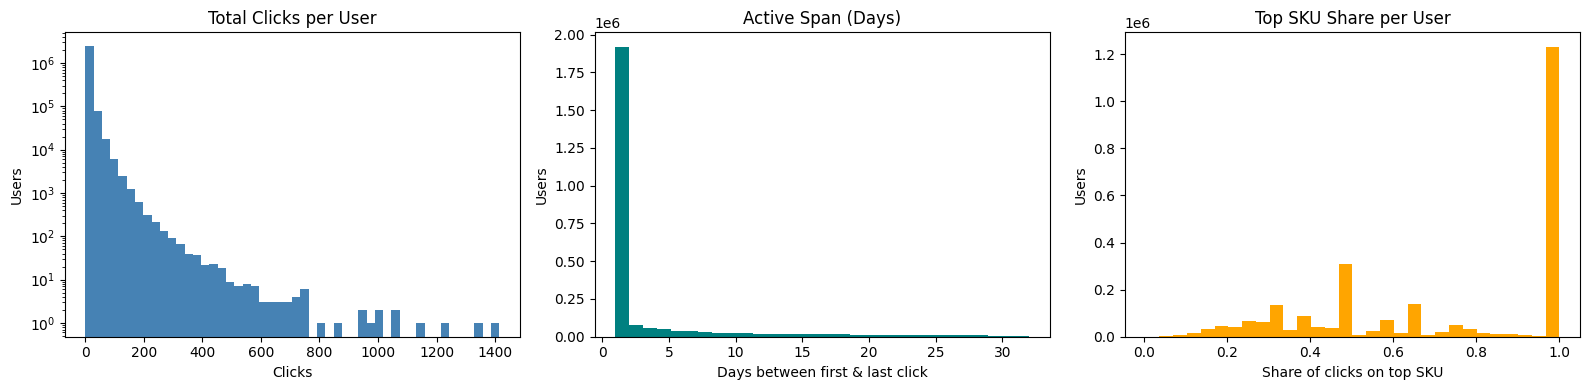

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(beh['total_clicks'], bins=50, color='steelblue')
axes[0].set_title('Total Clicks per User')
axes[0].set_xlabel('Clicks')
axes[0].set_ylabel('Users')
axes[0].set_yscale('log')  # heavy tail

axes[1].hist(beh['active_span_days'], bins=30, color='teal')
axes[1].set_title('Active Span (Days)')
axes[1].set_xlabel('Days between first & last click')
axes[1].set_ylabel('Users')

axes[2].hist(beh['top_sku_share'], bins=30, color='orange')
axes[2].set_title('Top SKU Share per User')
axes[2].set_xlabel('Share of clicks on top SKU')
axes[2].set_ylabel('Users')

plt.tight_layout()


### Channel Usage
Which channel dominates a user's clicks?


,pct_users
top_channel,
app,78.14
wechat,15.10
pc,2.83
mobile,2.79
others,1.13


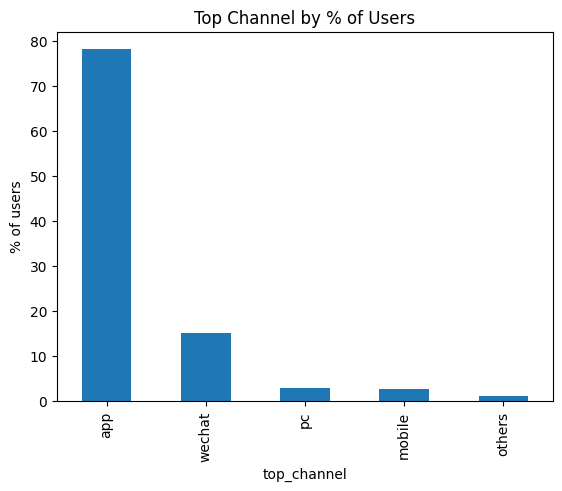

In [4]:
channel_counts = beh['top_channel'].value_counts(normalize=True).mul(100).round(2)
display(channel_counts.to_frame('pct_users'))
channel_counts.plot(kind='bar', title='Top Channel by % of Users')
plt.ylabel('% of users')
plt.show()


### Timing Patterns
Peak hour and peak day-of-week are *the time when each user clicks the most*.
This shows **when users tend to be most active**.


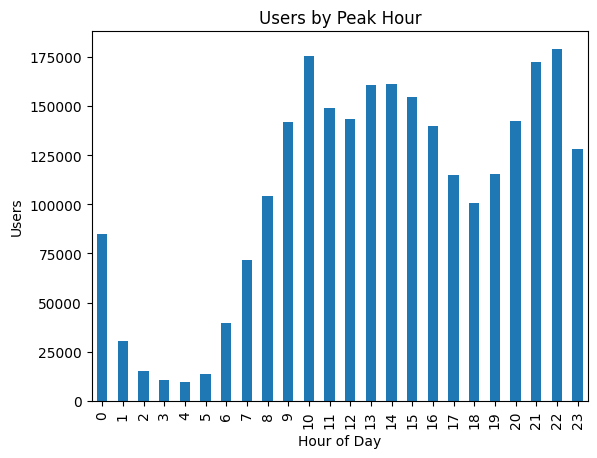

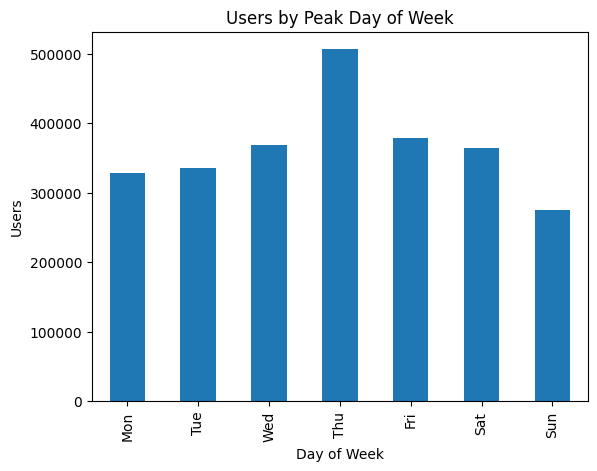

In [5]:
# Peak hour distribution
peak_hour_counts = beh['peak_hour'].value_counts().sort_index()
peak_hour_counts.plot(kind='bar', title='Users by Peak Hour')
plt.ylabel('Users')
plt.xlabel('Hour of Day')
plt.show()

# Peak day of week distribution
peak_dow_counts = beh['peak_dow'].value_counts()
peak_dow_counts = peak_dow_counts.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
peak_dow_counts.plot(kind='bar', title='Users by Peak Day of Week')
plt.ylabel('Users')
plt.xlabel('Day of Week')
plt.show()


## 2. SKU Performance (User-Level)
We can evaluate which SKUs are **most frequently a user's top SKU**.
This is not total clicks across all events, but it is a strong proxy for *which SKUs dominate user attention*.


,unique_users
top_sku,
068f4481b3,156785
3c79df1d80,63175
8dc4a01dec,56468
7e4cb4952a,41149
adfedb6893,39711
fbce41fd82,35987
17054160bd,33859
38d636d2a6,32627
ca7647a231,31284


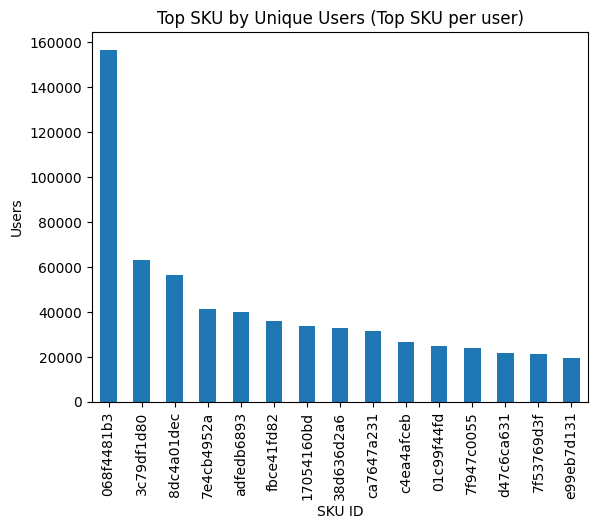

In [6]:
# Top clicked SKU by number of unique users
top_sku_by_users = beh['top_sku'].value_counts().head(15)
display(top_sku_by_users.to_frame('unique_users'))

top_sku_by_users.plot(kind='bar', title='Top SKU by Unique Users (Top SKU per user)')
plt.ylabel('Users')
plt.xlabel('SKU ID')
plt.show()


In [20]:
top_sku_by_users = beh['top_sku'].value_counts().head(15).reset_index()
print(top_sku_by_users['top_sku'].to_list())

['068f4481b3', '3c79df1d80', '8dc4a01dec', '7e4cb4952a', 'adfedb6893', 'fbce41fd82', '17054160bd', '38d636d2a6', 'ca7647a231', 'c4ea4afceb', '01c99f44fd', '7f947c0055', 'd47c6ca631', '7f53769d3f', 'e99eb7d131']


In [21]:
sku = pd.read_csv('../data/raw/JD_sku_data.csv')
top_skus = sku[sku['sku_ID'].isin(['068f4481b3', '3c79df1d80', '8dc4a01dec', '7e4cb4952a', 'adfedb6893', 'fbce41fd82', '17054160bd', '38d636d2a6', 'ca7647a231', 'c4ea4afceb', '01c99f44fd', '7f947c0055', 'd47c6ca631', '7f53769d3f', 'e99eb7d131'])]
display(top_skus)

,sku_ID,type,brand_ID,attribute1,attribute2,activate_date,deactivate_date
160,7f947c0055,1,a2ff0f7b48,3.0,100.0,NaN,NaN
256,8dc4a01dec,1,43999af013,3.0,100.0,NaN,NaN
362,7f53769d3f,1,0b0f75e8d5,4.0,100.0,NaN,NaN
956,e99eb7d131,2,7f65198ef6,4.0,100.0,NaN,NaN
1148,7e4cb4952a,1,5ab8ea8556,2.0,80.0,NaN,NaN
1294,fbce41fd82,1,99d41501ff,3.0,100.0,NaN,NaN
1501,adfedb6893,1,3daeabd2ce,3.0,100.0,NaN,NaN
1731,3c79df1d80,1,9b0d3a5fc6,3.0,60.0,NaN,NaN
1771,c4ea4afceb,1,3daeabd2ce,2.0,30.0,NaN,NaN
1772,ca7647a231,1,5ab8ea8556,3.0,90.0,NaN,NaN
